 Device Info:
CUDA available : True
CUDA version   : 12.1
Using device   : cuda
GPU            : NVIDIA GeForce RTX 3050 6GB Laptop GPU  (6143 MB)
Save dir    : convae_results/
 Load & preprocess:
Available keys: ['X_jets', 'm0', 'pt', 'y']
X_jets shape : (10000, 125, 125, 3)
Labels       : {0: 4994, 1: 5006}
Majority class : 50.1%
Preprocessed shape : (10000, 3, 125, 125)
Value range        : [0.0000, 1.0000]
Train :  8000 samples  (63 batches)
Val   :  2000 samples  (16 batches)
 Data Visualization:


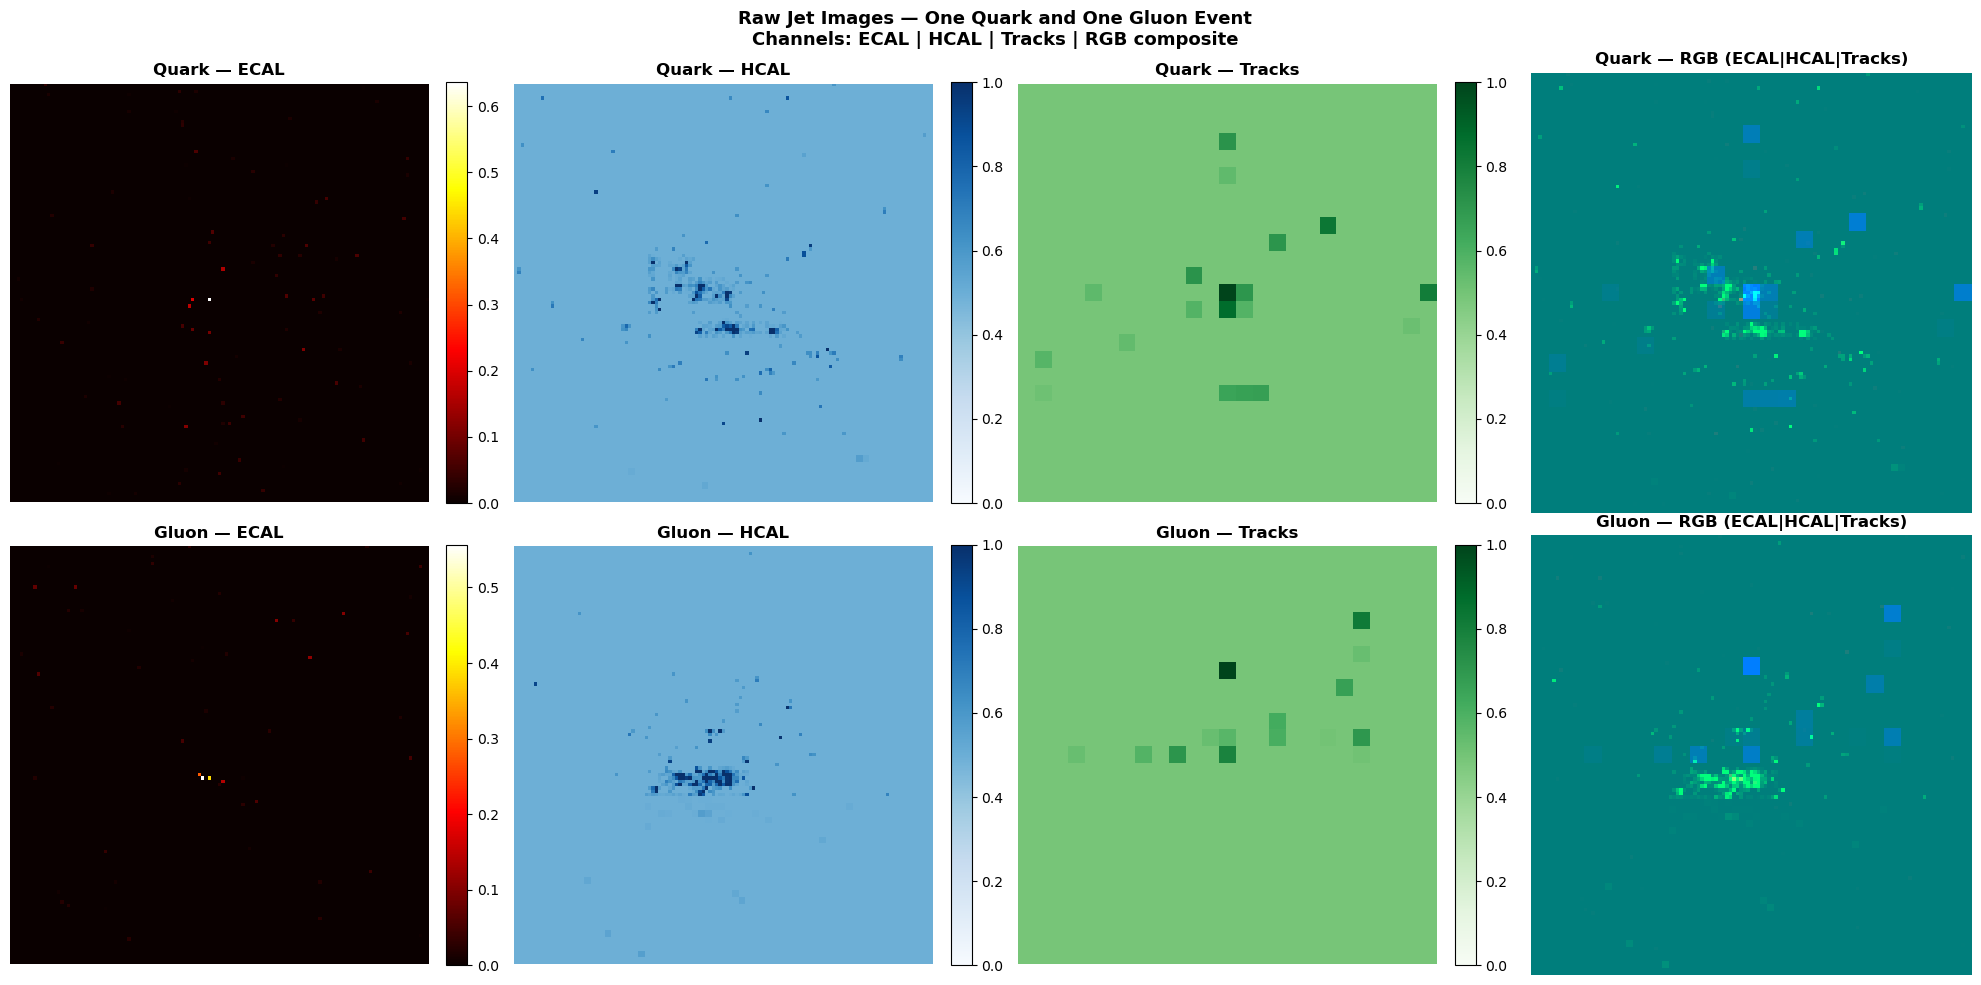

Per-channel stats (preprocessed):
  ECAL    : mean=0.0002  std=0.0078  nonzero=0.004  max=1.0000
  HCAL    : mean=0.4981  std=0.0238  nonzero=1.000  max=1.0000
  Tracks  : mean=0.4955  std=0.0445  nonzero=1.000  max=1.0000


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import h5py
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# # uncomment if using Google Colab

# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)
# print("Drive mounted successfully")
#Config
# ── All hyperparameters in one place ──────────────────────────────────
DATA_PATH   = r'C:\Users\ASUS\ML Code\Deep Graph Anomaly Detection\Data\quark-gluon_data-set_n139306.hdf5' # Place file link here
SAVE_DIR    = 'convae_results'
MAX_SAMPLES = 10000
VAL_FRAC     = 0.2
BATCH_SIZE   = 128

CHANNEL_NAMES = ['ECAL', 'HCAL', 'Tracks']
CHANNEL_CMAPS = ['hot',  'Blues', 'Greens']


# ── Device Check ───────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(''+'='*100 + '\n Device Info:\n' + '='*100)
print(f'CUDA available : {torch.cuda.is_available()}')
print(f'CUDA version   : {torch.version.cuda}')
print(f'Using device   : {device}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU            : {props.name}  ({props.total_memory // 1024**2} MB)')





os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save dir    : {SAVE_DIR}/')

def load_data(filepath):
    """
    Returns numpy arrays.
    """
    with h5py.File(filepath, 'r') as f:
        print('Available keys:', list(f.keys()))
        X_jets = f['X_jets'][:MAX_SAMPLES]   # load fully into RAM
        y_jets = f['y'][:MAX_SAMPLES]
        m0     = f['m0'][:MAX_SAMPLES] if 'm0' in f else None
        pt     = f['pt'][:MAX_SAMPLES] if 'pt' in f else None

    print(f'X_jets shape : {X_jets.shape}')   # (N, 125, 125, 3)
    unique, counts = np.unique(y_jets, return_counts=True)
    print(f'Labels       : { {int(k): int(v) for k,v in zip(unique, counts)} }')
    print(f'Majority class : {max(counts)/sum(counts):.1%}')
    return X_jets, y_jets.astype(np.int64)


def preprocess_data(X_jets, max_samples=10000):
    """

    Channel 0 (ECAL)  : log1p transform + percentile + high-energy emphasis
    Channel 1 (HCAL)  : standard scaling → [0,1]
    Channel 2 (Tracks): standard scaling → [0,1]

    Returns:
        normalized_data  : (N, 3, 125, 125)  float32  in [0,1]
        scale_factors    : list of (p_low, scale, transform_type) per channel
    """
    n_samples        = min(max_samples, X_jets.shape[0])
    X_jets_subset    = X_jets[:n_samples]  # (N, 125, 125, 3)

    # HWC → CHW
    X               = np.transpose(X_jets_subset, (0, 3, 1, 2)).astype(np.float32)
    normalized_data = np.zeros_like(X, dtype=np.float32)
    scale_factors   = []

    for c in range(X.shape[1]):
        channel_data = X[:, c, :, :]

        if c == 0:   # ECAL  — log transform + percentile scaling + high-energy emphasis
            eps              = 1e-8
            transformed_data = np.log1p(channel_data * 10 + eps) / 3.0
            non_zero_mask    = channel_data > 0
            if np.any(non_zero_mask):
                p_low, p_high = np.percentile(transformed_data[non_zero_mask], [1, 99.9])
            else:
                p_low, p_high = 0, 1
            scale = p_high - p_low
            if scale < 1e-10:
                p_low, p_high, scale = 0, 1.0, 1.0
            normalized_channel          = (transformed_data - p_low) / scale
            high_energy_mask            = normalized_channel > 0.75
            normalized_channel[high_energy_mask] = (
                0.75 + (normalized_channel[high_energy_mask] - 0.75) * 1.5
            )
            transform_type = 'energy_log'

        else:   # HCAL & Tracks — standard scaling
            if np.std(channel_data) > 1e-10:
                mean, std        = np.mean(channel_data), np.std(channel_data)
                normalized_channel = (channel_data - mean) / (3 * std)
                normalized_channel = np.clip(normalized_channel, -1, 1) * 0.5 + 0.5
                p_low, scale     = mean, 3 * std
                transform_type   = 'standard'
            else:
                normalized_channel = channel_data.copy()
                p_low, scale       = 0, 1
                transform_type     = 'identity'

        normalized_data[:, c, :, :] = normalized_channel
        scale_factors.append((p_low, scale, transform_type))

    normalized_data = np.clip(np.nan_to_num(normalized_data), 0.0, 1.0)
    print(f'Preprocessed shape : {normalized_data.shape}')
    print(f'Value range        : [{normalized_data.min():.4f}, {normalized_data.max():.4f}]')
    return normalized_data, scale_factors


# ── Load & preprocess ─────────────────────────────────────────────────
print(''+'='*100 + '\n Load & preprocess:\n' + '='*100)
X_jets, y_jets = load_data(DATA_PATH)
X_proc, scale_factors = preprocess_data(X_jets, MAX_SAMPLES)

X_tensor = torch.tensor(X_proc,  dtype=torch.float32)
y_tensor = torch.tensor(y_jets[:MAX_SAMPLES], dtype=torch.long)

# Stratified train/val split  (same random_state=42 as Rushil)
tr_idx, va_idx = train_test_split(
    np.arange(len(X_tensor)), test_size=VAL_FRAC,
    random_state=SEED, stratify=y_tensor.numpy()
)
X_train, X_val = X_tensor[tr_idx], X_tensor[va_idx]
y_train, y_val = y_tensor[tr_idx], y_tensor[va_idx]

# num_workers=0  required on Windows
train_loader = DataLoader(TensorDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(TensorDataset(X_val, y_val),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)


print(f'Train : {len(X_train):5d} samples  ({len(train_loader)} batches)')
print(f'Val   : {len(X_val):5d} samples  ({len(val_loader)} batches)')


print(''+'='*100 + '\n Data Visualization:\n' + '='*100)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Raw Jet Images — One Quark and One Gluon Event\nChannels: ECAL | HCAL | Tracks | RGB composite',
             fontweight='bold', fontsize=13)

q_idx = int((y_tensor == 0).nonzero(as_tuple=True)[0][0])
g_idx = int((y_tensor == 1).nonzero(as_tuple=True)[0][0])

for row, (evt_idx, evt_name) in enumerate([(q_idx, 'Quark'), (g_idx, 'Gluon')]):
    img = X_proc[evt_idx]   # (3, 125, 125)

    for ch in range(3):
        ax = axes[row, ch]
        im = ax.imshow(img[ch], cmap=CHANNEL_CMAPS[ch], vmin=0, aspect='equal')
        ax.set_title(f'{evt_name} — {CHANNEL_NAMES[ch]}', fontweight='bold')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # RGB composite
    rgb = np.stack([img[0], img[1], img[2]], axis=-1)
    rgb = np.clip(rgb, 0, 1)
    axes[row, 3].imshow(rgb, aspect='equal')
    axes[row, 3].set_title(f'{evt_name} — RGB (ECAL|HCAL|Tracks)', fontweight='bold')
    axes[row, 3].axis('off')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/data_exploration.png', dpi=130, bbox_inches='tight')
plt.show()

print('Per-channel stats (preprocessed):')
for c, name in enumerate(CHANNEL_NAMES):
    ch = X_proc[:, c]
    nz_frac = (ch > 0.01).mean()
    print(f'  {name:<8}: mean={ch.mean():.4f}  std={ch.std():.4f}  '
          f'nonzero={nz_frac:.3f}  max={ch.max():.4f}')

# Common Task 1
### Convolutional Autoencoder — Quark/Gluon Jet Reconstruction

> **Task:** Train an autoencoder to learn the representation based on three image channels  
> (ECAL, HCAL, Tracks). Show a side-by-side comparison of original vs reconstructed events.

---

**Architecture — Convolutional AE**
```
Input  (B, 3, 125, 125)

ENCODER 
  Conv2d(  3→ 32, k=4,s=2,p=1) + BN + LeakyReLU(0.2)  →  (B, 32, 62, 62)
  Conv2d( 32→ 64, k=4,s=2,p=1) + BN + LeakyReLU(0.2)  →  (B, 64, 31, 31)
  Conv2d( 64→128, k=4,s=2,p=1) + BN + LeakyReLU(0.2)  →  (B,128, 15, 15)
  Conv2d(128→256, k=4,s=2,p=1) + BN + LeakyReLU(0.2)  →  (B,256,  7,  7)
  Conv2d(256→512, k=4,s=2,p=1) + BN + LeakyReLU(0.2)  →  (B,512,  3,  3)
  Flatten  →  (B, 4608)
  Linear(4608 → 256)  ← BOTTLENECK  z

DECODER 
  Linear(256 → 4608) → Reshape (B,512,3,3)
  ConvTranspose2d(512→256, k=4,s=2,p=1) + BN + ReLU  →  (B,256,  6,  6)
  ConvTranspose2d(256→128, k=4,s=2,p=1) + BN + ReLU  →  (B,128, 12, 12)
  ConvTranspose2d(128→ 64, k=4,s=2,p=1) + BN + ReLU  →  (B, 64, 24, 24)
  ConvTranspose2d( 64→ 32, k=4,s=2,p=1) + BN + ReLU  →  (B, 32, 48, 48)
  ConvTranspose2d( 32→  3, k=4,s=2,p=1) + Sigmoid    →  (B,  3, 96, 96)
  F.interpolate(bilinear)               →  (B,  3,125,125)

LOSS  
  importance_weights = 1 + original * 4          (high-energy pixels up to 5×)
  loss = sum( weights * (recon - orig)² )
```


 shape and Parameter check:
Parameters          : 7,942,211
Encoder output size : (512, 3, 3)
Flatten size        : 4608
Bottleneck (latent) : 256

Shape check:
  Input  : (2, 3, 125, 125)
  z      : (2, 256)   ← bottleneck
  Output : (2, 3, 125, 125)   ← reconstruction
All shapes OK.
 Training Loop:
Training ConvAE  (max 50 epochs, early stopping patience=15)
──────────────────────────────────────────────────────────────────────


Ep   1/50  train=948.84911  val=138.12802  lr=1.00e-03  *  saved


Ep   2/50  train=114.76943  val=113.37354  lr=1.00e-03  *  saved


Ep   3/50  train=102.39692  val=110.93469  lr=1.00e-03  *  saved


Ep   4/50  train=97.92630  val=99.74756  lr=1.00e-03  *  saved


...

Ep  46/50  train=46.33663  val=50.53771  lr=1.00e-03  *  saved


Ep  47/50  train=44.33407  val=50.69218  lr=1.00e-03


Ep  48/50  train=43.89679  val=49.65525  lr=1.00e-03  *  saved


Ep  49/50  train=43.10987  val=49.20669  lr=1.00e-03  *  saved


Ep  50/50  train=42.89335  val=51.13862  lr=1.00e-03

Best val loss : 49.20669
Best model loaded.
 Original vs. Reconstructed:
Saved: convae_results/side_by_side_comparison.png


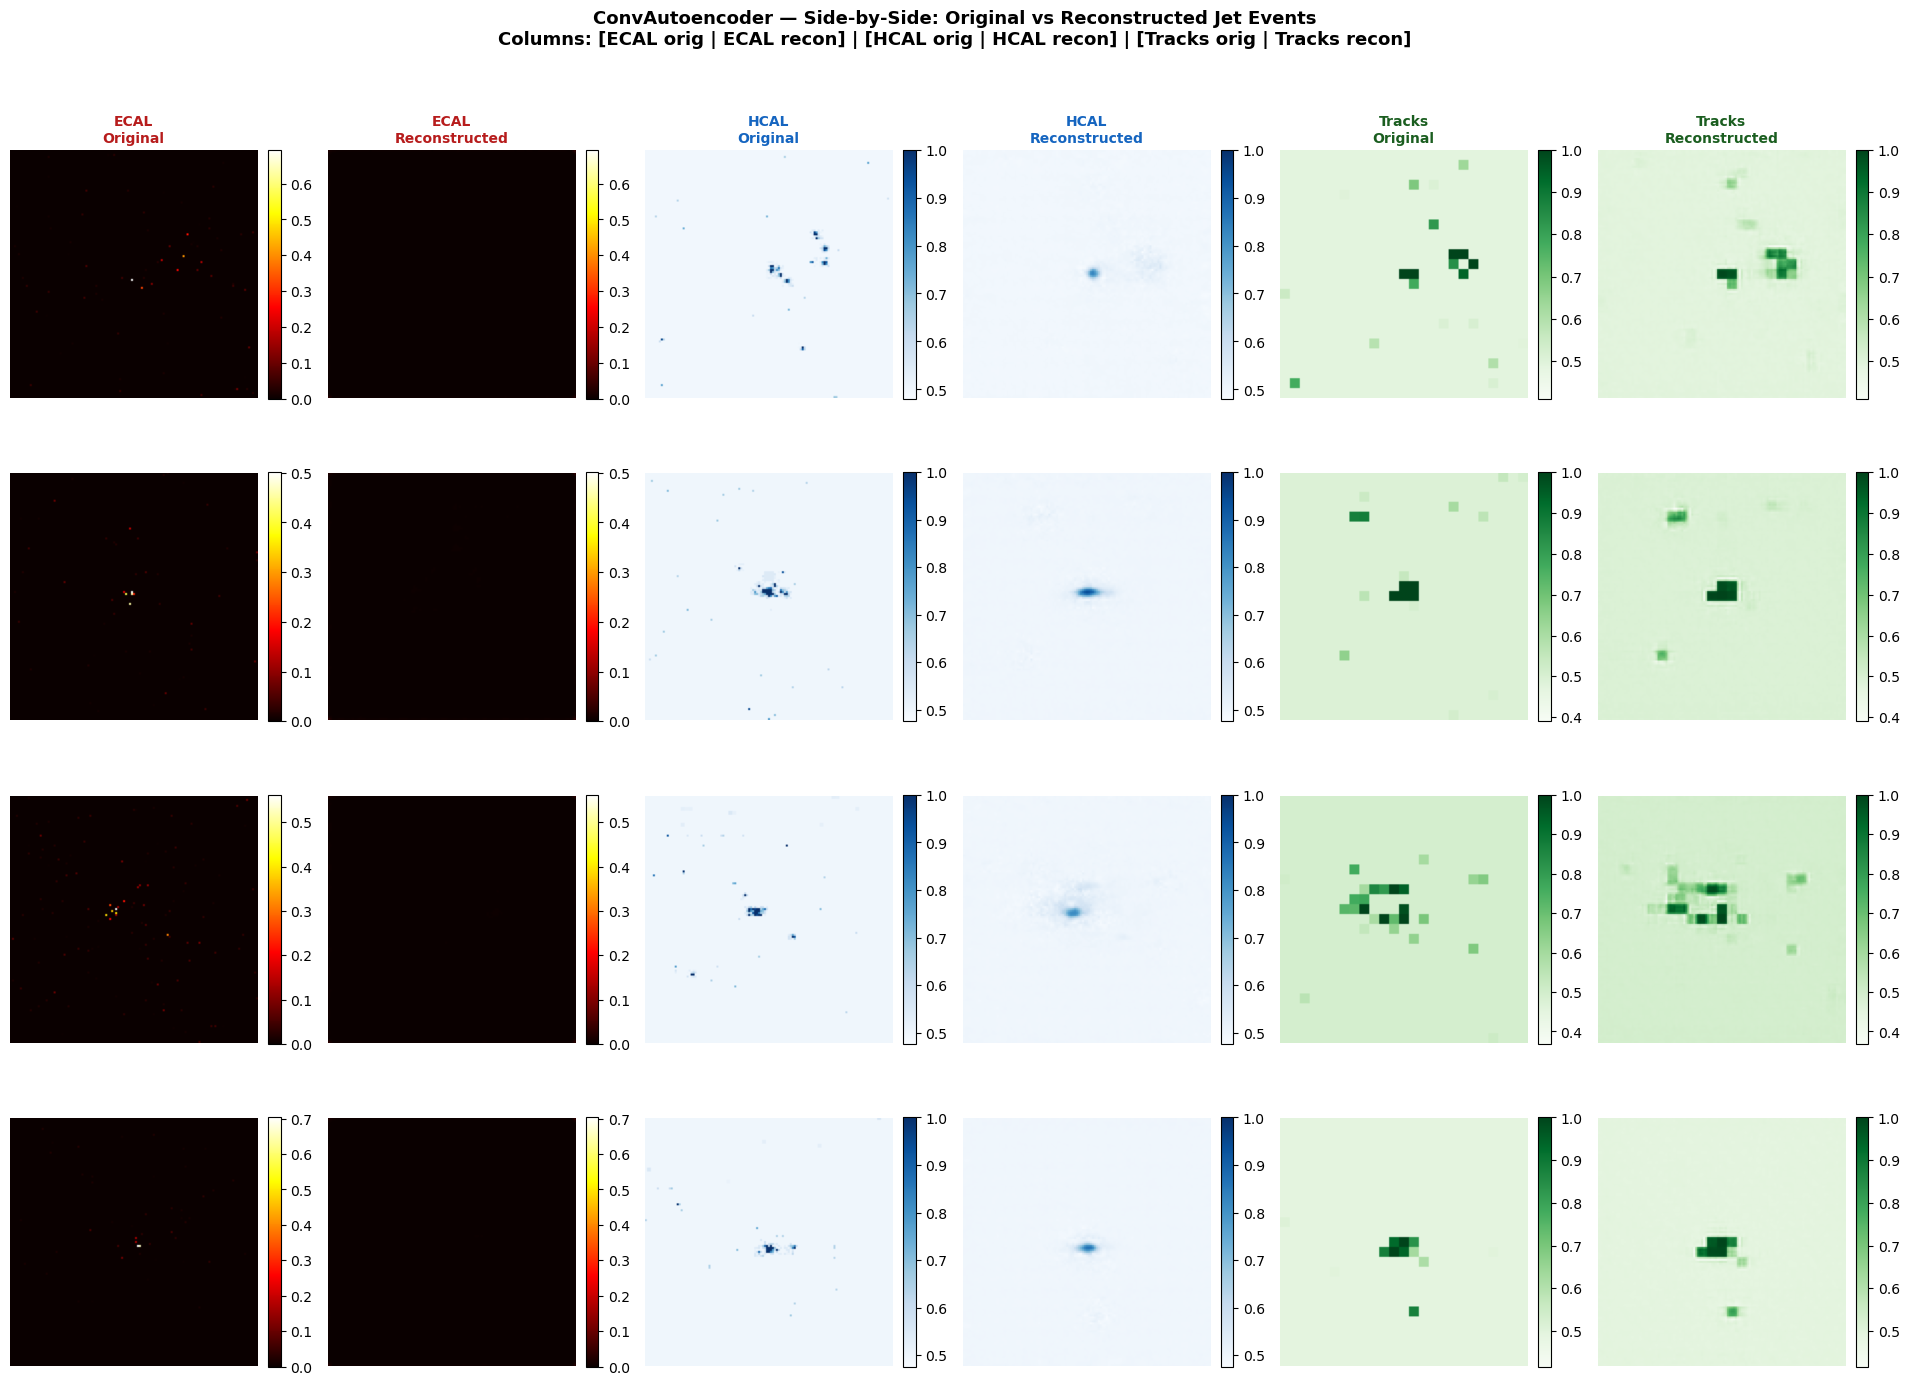

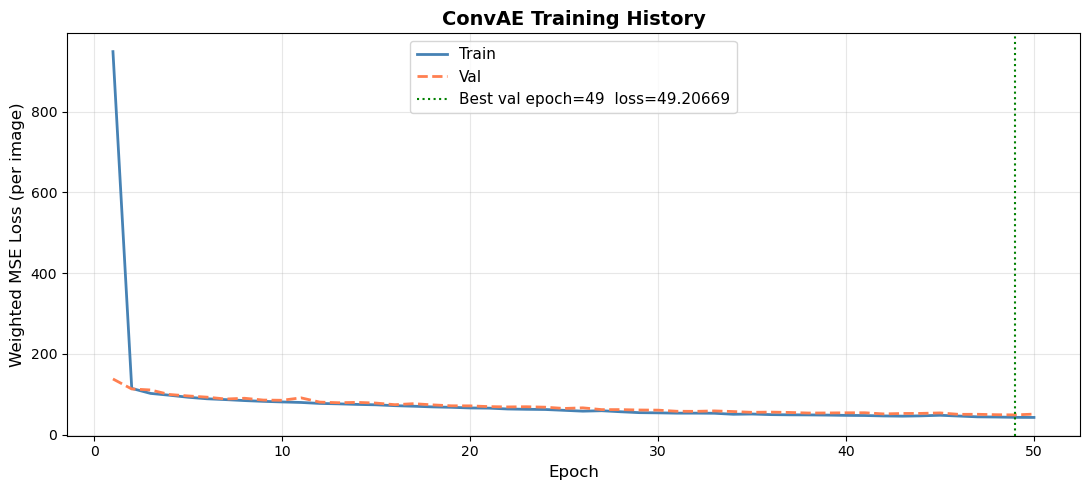

Saved: convae_results/training_curves.png


 Reconstruction Metric:
  MSE   : 0.000263
  MAE   : 0.003387
  RMSE  : 0.016224
  NRMSE : 0.016224
  PSNR  : 35.797087 dB

Per-channel MSE:
  ECAL    : 0.000064
  HCAL    : 0.000423
  Tracks  : 0.000302

Quark MSE : 0.000299 ± 0.000160
Gluon MSE : 0.000228 ± 0.000119
 Error Distribution — Quark vs Gluon:


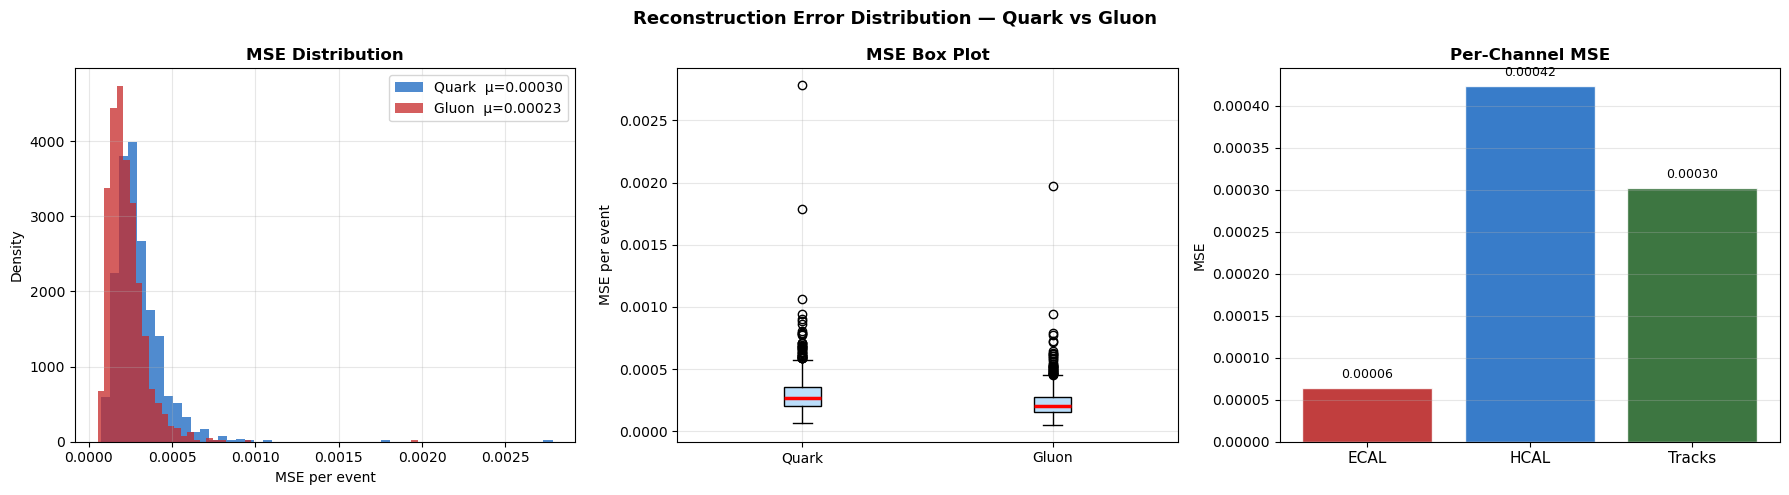

Saved: convae_results/error_distribution.png
  COMMON TASK 1 — Convolutional Autoencoder  |  SUMMARY

Architecture  (AE bottleneck)
  ENCODER  Conv2d(3→32→64→128→256→512, k=4,s=2,p=1)
           BN + LeakyReLU(0.2) after each layer
           Flatten(4608) → Linear → z(256)  ← bottleneck
  DECODER  z(256) → Linear → Reshape(512,3,3)
           ConvTranspose2d(512→256→128→64→32→3, k=4,s=2,p=1)
           BN+ReLU per layer, Sigmoid final, interpolate→125×125
  Params   7,942,211

Training
  Samples  : 10000 (train=8000, val=2000)
  Loss     : Physics-aware weighted MSE
             importance = 1 + orig×4  (high-energy pixels 5×)
  Epochs   : 50 trained  |  best at ep 49
  Batch    : 128, lr=0.001, grad_clip=0.5

Results (Validation Set)
  MSE   : 0.000263
  MAE   : 0.003387
  RMSE  : 0.016224
  NRMSE : 0.016224
  PSNR  : 35.797087 dB
  Quark MSE : 0.000299
  Gluon MSE : 0.000228

Per-channel MSE
  ECAL    : 0.000064
  HCAL    : 0.000423
  Tracks  : 0.000302

Saved files
  convae_results

In [ ]:
class Config:
# ── Config ───────────────────────────────────────────────────────
    MAX_SAMPLES = 10000      
    VAL_FRAC    = 0.20

    # Architecture
    IN_CHANNELS = 3          # ECAL, HCAL, Tracks
    LATENT_DIM  = 256        # bottleneck 

    # Training 
    BATCH_SIZE  = 32
    EPOCHS      = 50
    LR          = 1e-3      
    LR_PATIENCE = 8
    LR_FACTOR   = 0.5
    GRAD_CLIP   = 0.5        
    ES_PATIENCE = 15


class ConvAutoencoder(nn.Module):
    """
    Convolutional Autoencoder.

    """

    def __init__(self, in_channels=3, latent_dim=256, input_size=(125, 125)):
        super().__init__()

       
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32,  kernel_size=4, stride=2, padding=1),   # 125→62
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32,  64,  kernel_size=4, stride=2, padding=1),           # 62→31
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,  128, kernel_size=4, stride=2, padding=1),           # 31→15
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),           # 15→7
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),           # 7→3
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
        )

        self.encoder_output_size = self._get_encoder_output_size(in_channels, input_size)
        self.flatten_size        = int(np.prod(self.encoder_output_size))  # 4608

        self.fc_z  = nn.Linear(self.flatten_size, latent_dim)

     
        self.fc_up = nn.Linear(latent_dim, self.flatten_size)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),  # 3→6
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 6→12
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64,  kernel_size=4, stride=2, padding=1),  # 12→24
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64,  32,  kernel_size=4, stride=2, padding=1),  # 24→48
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32,  in_channels, kernel_size=4, stride=2, padding=1),  # 48→96
            nn.Sigmoid(),
        )

    def _get_encoder_output_size(self, in_channels, input_size):
        """Manual calculation of encoder output size without a dummy tensor."""
        h, w = input_size
        for _ in range(5):
            h = (h + 2*1 - 4) // 2 + 1
            w = (w + 2*1 - 4) // 2 + 1
        return (512, h, w)   # (512, 3, 3)

    def encode(self, x):
        """Returns z  (B, latent_dim).  No mu/log_var — this is a plain AE."""
        x = self.encoder(x)              # (B, 512, 3, 3)
        x = x.view(x.size(0), -1)       # (B, 4608)
        z = self.fc_z(x)                # (B, latent_dim)
        return z

    def decode(self, z):
        x = self.fc_up(z)                                         # (B, 4608)
        x = x.view(x.size(0), *self.encoder_output_size)         # (B, 512, 3, 3)
        x = self.decoder(x)                                       # (B, 3, 96, 96)
        x = F.interpolate(x, size=(125, 125),
                          mode='bilinear', align_corners=False)   # (B, 3,125,125)
        return x

    def forward(self, x):
        z     = self.encode(x)
        recon = self.decode(z)
        return recon, z





"""
Loss — Physics-aware Weighted MSE

importance_weights = 1 + original × 4
 background pixel (value ≈ 0)  →  weight 1×
high-energy pixel  (value = 1) →  weight 5×

loss = Σ  weights × (recon − orig)²
"""


def ae_loss(reconstruction, original):
    """
    High-energy deposits get up to 5× more weight.
    """
    importance_weights = 1.0 + original * 4.0          # (B, 3, 125, 125)
    return torch.sum(importance_weights * (reconstruction - original) ** 2)


def evaluate_reconstruction(original_batch, reconstructed_batch):
    """
    MSE / MAE / RMSE / NRMSE / PSNR.
    """
    
    orig  = original_batch.cpu().numpy()
    recon = reconstructed_batch.detach().cpu().numpy()
    mse   = float(np.mean((orig - recon)**2))
    mae   = float(np.mean(np.abs(orig - recon)))
    rmse  = float(np.sqrt(mse))
    data_range = float(np.max(orig) - np.min(orig))
    nrmse = rmse / data_range if data_range > 1e-10 else rmse
    psnr  = float(20 * np.log10(1.0 / rmse)) if mse > 1e-10 else 100.0
    return {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'NRMSE': nrmse, 'PSNR': psnr}


def run_epoch(model, optimizer , loader, GRAD_CLIP, train=True):
    model.train() if train else model.eval()
    total, n = 0.0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    iterator = tqdm(loader, desc='Train' if train else 'Val ', leave=False, ncols=80)

    with ctx:
        for (x, _) in iterator:
            x     = x.to(device)
            recon, _ = model(x)
            loss  = ae_loss(recon, x)

            if torch.isnan(loss) or torch.isinf(loss):
                print('Warning: NaN/Inf loss — skipping batch')
                continue

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
                optimizer.step()

            total += loss.item() / x.size(0)   # normalise by batch size
            n     += 1
            iterator.set_postfix({'loss': f'{loss.item()/x.size(0):.4f}'})

    return total / n if n > 0 else float('inf')


@torch.no_grad()
def visualize_reconstruction(model, val_loader, n_events=4,
                              save_path=None):
    """

    Layout (n_events rows, 6 cols):
      Col 0,1 : Original ECAL    | Recon ECAL
      Col 2,3 : Original HCAL    | Recon HCAL
      Col 4,5 : Original Tracks  | Recon Tracks

    """
    model.eval()

    # Collect n_events samples: half Quark, half Gluon
    all_x, all_y = [], []
    for (xb, yb) in val_loader:
        all_x.append(xb); all_y.append(yb)
        if sum(a.size(0) for a in all_x) >= n_events * 4:
            break
    all_x = torch.cat(all_x); all_y = torch.cat(all_y)

    q_idx = (all_y == 0).nonzero(as_tuple=True)[0][:n_events//2].tolist()
    g_idx = (all_y == 1).nonzero(as_tuple=True)[0][:n_events//2].tolist()
    sel   = q_idx + g_idx
    labels = ['Quark'] * len(q_idx) + ['Gluon'] * len(g_idx)

    x_sel   = all_x[sel].to(device)
    recon_b, _ = model(x_sel)

    orig_np  = x_sel.cpu().numpy()       # (n_events, 3, 125, 125)
    recon_np = recon_b.cpu().numpy()

    n_ch = 3
    n_cols = n_ch * 2   # orig + recon per channel

    fig = plt.figure(figsize=(n_cols * 3.2, n_events * 3.5))
    fig.suptitle(
        'ConvAutoencoder — Side-by-Side: Original vs Reconstructed Jet Events\n'
        'Columns: [ECAL orig | ECAL recon] | [HCAL orig | HCAL recon] | [Tracks orig | Tracks recon]',
        fontsize=13, fontweight='bold', y=1.01
    )

    # Column header annotations
    col_titles = [
        ('ECAL',   '#B71C1C'),
        ('HCAL',   '#1565C0'),
        ('Tracks', '#1B5E20'),
    ]

    for event_i in range(n_events):
        for ch in range(n_ch):
            o    = orig_np[event_i, ch]     # (125,125)
            r    = recon_np[event_i, ch]
            cmap = CHANNEL_CMAPS[ch]

            vmin = min(o.min(), r.min())
            vmax = max(o.max(), r.max())
            if vmax - vmin < 1e-8:
                vmax = vmin + 1.0

            mse_ch = float(np.mean((o - r)**2))
            lbl    = labels[event_i]

            # ── Original ─────────────────────────────────────────────
            ax_o = fig.add_subplot(n_events, n_cols, event_i * n_cols + ch * 2 + 1)
            im_o = ax_o.imshow(o, cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
            if event_i == 0:
                ax_o.set_title(f'{col_titles[ch][0]}\nOriginal',
                               fontsize=10, fontweight='bold',
                               color=col_titles[ch][1])
            if ch == 0:
                ax_o.set_ylabel(lbl, fontsize=11, fontweight='bold',
                                color='#1a237e' if lbl=='Quark' else '#b71c1c')
            ax_o.axis('off')
            plt.colorbar(im_o, ax=ax_o, fraction=0.046, pad=0.04)

            # ── Reconstructed ────────────────────────────────────────
            ax_r = fig.add_subplot(n_events, n_cols, event_i * n_cols + ch * 2 + 2)
            im_r = ax_r.imshow(r, cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
            if event_i == 0:
                ax_r.set_title(f'{col_titles[ch][0]}\nReconstructed',
                               fontsize=10, fontweight='bold',
                               color=col_titles[ch][1])
            ax_r.set_xlabel(f'MSE={mse_ch:.5f}', fontsize=8)
            ax_r.axis('off')
            plt.colorbar(im_r, ax=ax_r, fraction=0.046, pad=0.04)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=140, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()

@torch.no_grad()
def full_evaluation(model, loader):
    """evaluate_reconstruction extended to full dataset."""
    model.eval()
    all_mse, all_mae, all_lbl = [], [], []
    ch_mse = np.zeros(3); n = 0

    for (x, y) in tqdm(loader, desc='Eval', leave=False):
        x = x.to(device)
        r, _ = model(x)
        o = x.cpu().numpy(); r = r.cpu().numpy()

        for b in range(o.shape[0]):
            all_mse.append(float(np.mean((o[b]-r[b])**2)))
            all_mae.append(float(np.mean(np.abs(o[b]-r[b]))))
            all_lbl.append(int(y[b]))

        ch_mse += ((o-r)**2).mean(axis=(0,2,3))
        n += 1

    ch_mse /= n
    mse   = float(np.mean(all_mse))
    mae   = float(np.mean(all_mae))
    rmse  = float(np.sqrt(mse))
    nrmse = rmse  # features in [0,1]
    psnr  = float(20 * np.log10(1.0/rmse)) if rmse > 1e-10 else 100.0

    return {
        'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'NRMSE': nrmse, 'PSNR': psnr,
        'per_mse': np.array(all_mse),
        'labels' : np.array(all_lbl),
        'ch_mse' : ch_mse
    }

def start():
    # ── Instantiate ───────────────────────────────────────────────────────
    cfg = Config()
    model = ConvAutoencoder(cfg.IN_CHANNELS, cfg.LATENT_DIM).to(device)
    print(''+'='*100 + '\n shape and Parameter check:\n' + '='*100)

    n_params = sum(p.numel() for p in model.parameters())
    print(f'Parameters          : {n_params:,}')
    print(f'Encoder output size : {model.encoder_output_size}')
    print(f'Flatten size        : {model.flatten_size}')
    print(f'Bottleneck (latent) : {cfg.LATENT_DIM}')

    # Shape verification
    with torch.no_grad():
        _x = torch.randn(2, 3, 125, 125).to(device)
        _r, _z = model(_x)
        assert _r.shape == _x.shape, f'Shape mismatch: {_r.shape} != {_x.shape}'
        print(f'\nShape check:')
        print(f'  Input  : {tuple(_x.shape)}')
        print(f'  z      : {tuple(_z.shape)}   ← bottleneck')
        print(f'  Output : {tuple(_r.shape)}   ← reconstruction')
    print('All shapes OK.')
    #Training loop 
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=cfg.LR_FACTOR, patience=cfg.LR_PATIENCE, min_lr=1e-6
    )

    train_losses, val_losses = [], []
    best_val, es_ctr = float('inf'), 0



    print(''+'='*100 + '\n Training Loop:\n' + '='*100)

    print(f'Training ConvAE  (max {cfg.EPOCHS} epochs, early stopping patience={cfg.ES_PATIENCE})')
    print('─' * 70)

    for ep in range(1, cfg.EPOCHS + 1):
        tr = run_epoch(model, optimizer, train_loader, cfg.GRAD_CLIP, train=True)
        va = run_epoch(model, optimizer, val_loader, cfg.GRAD_CLIP, train=False)

        if not (np.isnan(va) or np.isinf(va)):
            scheduler.step(va)

        train_losses.append(tr)
        val_losses.append(va)

        lr_now = optimizer.param_groups[0]['lr']
        tag    = ''

        if va < best_val:
            best_val = va
            torch.save(model.state_dict(), f'{SAVE_DIR}/best_convae.pt')
            es_ctr = 0; tag = '  *  saved'
        else:
            es_ctr += 1
            if es_ctr >= cfg.ES_PATIENCE:
                print(f'Early stopping at epoch {ep}')
                break

        print(f'Ep {ep:3d}/{cfg.EPOCHS}  train={tr:.5f}  val={va:.5f}  '
            f'lr={lr_now:.2e}{tag}')

    # Reload best weights
    model.load_state_dict(torch.load(f'{SAVE_DIR}/best_convae.pt',
                                    weights_only=True, map_location=device))
    print(f'\nBest val loss : {best_val:.5f}')
    print('Best model loaded.')


    print(''+'='*100 + '\n Original vs. Reconstructed:\n' + '='*100)

    visualize_reconstruction(
        model, val_loader, n_events=4,
        save_path=f'{SAVE_DIR}/side_by_side_comparison.png'
    )


    tr_clean  = [x for x in train_losses if not (np.isnan(x) or np.isinf(x))]
    va_clean  = [x for x in val_losses   if not (np.isnan(x) or np.isinf(x))]
    best_ep   = int(np.argmin(va_clean)) + 1

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(range(1, len(tr_clean)+1), tr_clean, lw=2, color='steelblue', label='Train')
    ax.plot(range(1, len(va_clean)+1), va_clean, lw=2, color='coral',     label='Val', ls='--')
    ax.axvline(best_ep, color='green', ls=':', lw=1.5,
            label=f'Best val epoch={best_ep}  loss={best_val:.5f}')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Weighted MSE Loss (per image)', fontsize=12)
    ax.set_title('ConvAE Training History', fontweight='bold', fontsize=14)
    ax.legend(fontsize=11); ax.grid(alpha=0.3)
    plt.tight_layout()
    save_p = f'{SAVE_DIR}/training_curves.png'
    plt.savefig(save_p, dpi=140, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_p}')


    """
    Side-by-Side Comparison — Original vs Reconstructed
    *(Main required output for the task)*
    """

    metrics = full_evaluation(model, val_loader)


    print(''+'='*100 + '\n Reconstruction Metric:\n' + '='*100)
    for k in ['MSE','MAE','RMSE','NRMSE','PSNR']:
        unit = ' dB' if k == 'PSNR' else ''
        print(f'  {k:<6}: {metrics[k]:.6f}{unit}')

    print('\nPer-channel MSE:')
    for c, name in enumerate(CHANNEL_NAMES):
        print(f'  {name:<8}: {metrics["ch_mse"][c]:.6f}')

    q_mse = metrics['per_mse'][metrics['labels']==0]
    g_mse = metrics['per_mse'][metrics['labels']==1]
    print(f'\nQuark MSE : {q_mse.mean():.6f} ± {q_mse.std():.6f}')
    print(f'Gluon MSE : {g_mse.mean():.6f} ± {g_mse.std():.6f}')






    print(''+'='*100 + '\n Error Distribution — Quark vs Gluon:\n' + '='*100)
    q_mse = metrics['per_mse'][metrics['labels']==0]
    g_mse = metrics['per_mse'][metrics['labels']==1]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Reconstruction Error Distribution — Quark vs Gluon',
                fontweight='bold', fontsize=13)

    # Histogram
    axes[0].hist(q_mse, bins=50, alpha=0.75, color='#1565C0',
                density=True, label=f'Quark  μ={q_mse.mean():.5f}')
    axes[0].hist(g_mse, bins=50, alpha=0.75, color='#C62828',
                density=True, label=f'Gluon  μ={g_mse.mean():.5f}')
    axes[0].set_xlabel('MSE per event'); axes[0].set_ylabel('Density')
    axes[0].set_title('MSE Distribution', fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Box plot
    axes[1].boxplot(
        [q_mse, g_mse], labels=['Quark', 'Gluon'],
        patch_artist=True,
        boxprops=dict(facecolor='#BBDEFB'),
        medianprops=dict(color='red', lw=2.5)
    )
    axes[1].set_ylabel('MSE per event')
    axes[1].set_title('MSE Box Plot', fontweight='bold')
    axes[1].grid(alpha=0.3)

    # Per-channel bar
    x_pos = np.arange(3)
    bars  = axes[2].bar(x_pos, metrics['ch_mse'],
                        color=['#B71C1C','#1565C0','#1B5E20'],
                        edgecolor='white', alpha=0.85)
    axes[2].set_xticks(x_pos); axes[2].set_xticklabels(CHANNEL_NAMES, fontsize=11)
    axes[2].set_ylabel('MSE')
    axes[2].set_title('Per-Channel MSE', fontweight='bold')
    axes[2].grid(axis='y', alpha=0.3)
    for xi, v in zip(x_pos, metrics['ch_mse']):
        axes[2].text(xi, v + metrics['ch_mse'].max()*0.02,
                    f'{v:.5f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/error_distribution.png', dpi=140, bbox_inches='tight')
    plt.show()
    print(f'Saved: {SAVE_DIR}/error_distribution.png')

    #  Summary____________________________________________________________________
    best_ep = int(np.argmin(va_clean)) + 1

    print('='*60)
    print('  COMMON TASK 1 — Convolutional Autoencoder  |  SUMMARY')
    print('='*60)
    print()
    print('Architecture  (AE bottleneck)')
    print('  ENCODER  Conv2d(3→32→64→128→256→512, k=4,s=2,p=1)')
    print('           BN + LeakyReLU(0.2) after each layer')
    print('           Flatten(4608) → Linear → z(256)  ← bottleneck')
    print('  DECODER  z(256) → Linear → Reshape(512,3,3)')
    print('           ConvTranspose2d(512→256→128→64→32→3, k=4,s=2,p=1)')
    print('           BN+ReLU per layer, Sigmoid final, interpolate→125×125')
    print(f'  Params   {sum(p.numel() for p in model.parameters()):,}')
    print()
    print('Training')
    print(f'  Samples  : {MAX_SAMPLES} (train={len(X_train)}, val={len(X_val)})')
    print(f'  Loss     : Physics-aware weighted MSE')
    print(f'             importance = 1 + orig×4  (high-energy pixels 5×)')
    print(f'  Epochs   : {len(train_losses)} trained  |  best at ep {best_ep}')
    print(f'  Batch    : {BATCH_SIZE}, lr={cfg.LR}, grad_clip={cfg.GRAD_CLIP}')
    print()
    print('Results (Validation Set)')
    for k in ['MSE','MAE','RMSE','NRMSE','PSNR']:
        unit = ' dB' if k=='PSNR' else ''
        print(f'  {k:<6}: {metrics[k]:.6f}{unit}')
    print(f'  Quark MSE : {q_mse.mean():.6f}')
    print(f'  Gluon MSE : {g_mse.mean():.6f}')
    print()
    print('Per-channel MSE')
    for c, name in enumerate(CHANNEL_NAMES):
        print(f'  {name:<8}: {metrics["ch_mse"][c]:.6f}')
    print()
    print('Saved files')
    for f in ['best_convae.pt','training_curves.png',
            'side_by_side_comparison.png','residual_maps.png',
            'error_distribution.png','latent_pca.png']:
        print(f'  {SAVE_DIR}/{f}')


if __name__ == '__main__':
    start()

## ── Test Results ──────────────────────────
  # Accuracy : 72.90%
  # ROC-AUC  : 0.7877

              precision    recall  f1-score   support

       Quark       0.73      0.70      0.72       488
       Gluon       0.73      0.75      0.74       512

    accuracy                           0.73      1000
   macro avg       0.73      0.73      0.73      1000
weighted avg       0.73      0.73      0.73      1000


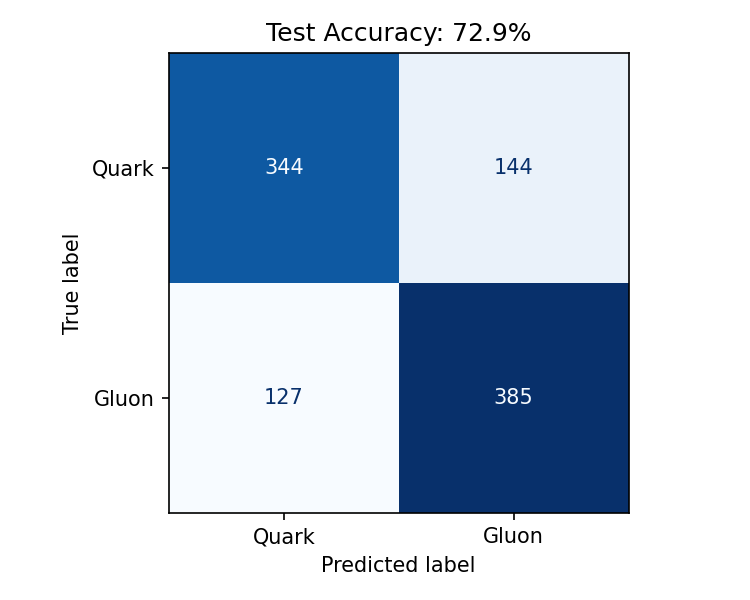
![alt text](outputs/cls_roc.png)
![alt text](outputs/cls_score_dist.png)
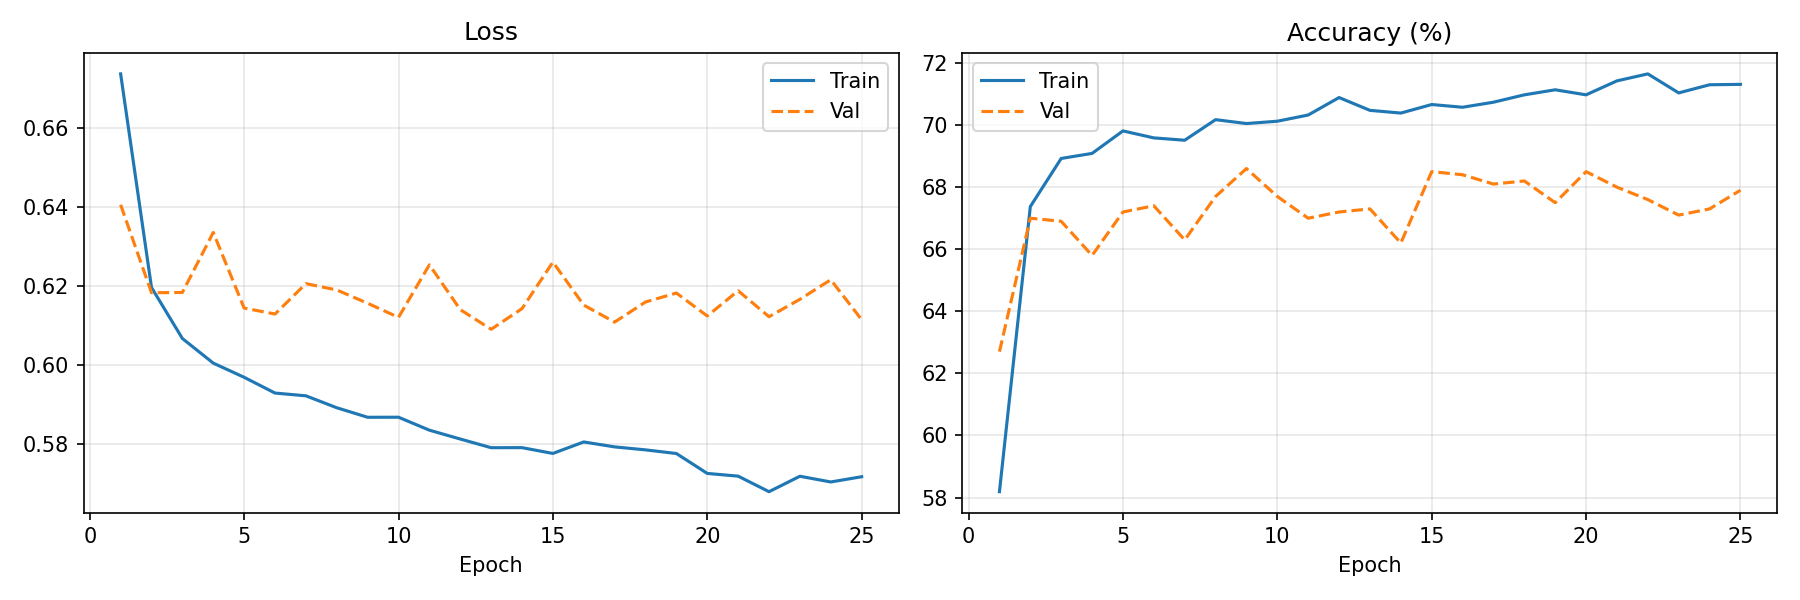